In [1]:
from deap import tools, creator, base, algorithms, benchmarks
import pymop
from math import factorial
from numpy import random
from meamt_core import generate_dtlz3_front_random, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "dtlz3"
NOBJ = 5
K = 10
NDIM = NOBJ + K - 1
P = 12
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_dtlz3_front_random(NOBJ, 1000)

In [2]:
MU = 1000
NGEN = 600
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)


In [3]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.dtlz3, obj=NOBJ)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

In [4]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        pop_comp = pop[:(int)(MU/(1 << NOBJ))]
        hv_val = hypervolume(pop_comp, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        approx_front_comp = approx_front[:(int)(MU/(1 << NOBJ))]
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front_comp)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)
        print(logbook.stream)

    return pop, logbook

In [5]:
pop, logbook = main()

gen	evals	std                                                               	min                                                     	avg                                                               	max                                                                    	hypervolume	igd_plus
0  	1000 	[215.01236182 236.0428088  287.23775477 338.83580031 370.54717259]	[0.03235645 0.04571017 0.02517193 0.00813713 0.68014349]	[181.08822691 185.44957415 287.10809111 441.01830268 671.65658677]	[1124.94133605 1382.27424292 1480.63720683 1498.30240126 1696.06702788]	           	        
1  	1000 	[243.6632177  264.11832823 323.36543563 331.54035473 321.24250555]	[0.00163528 0.04571017 0.02517193 0.00615036 0.08581761]	[199.11361707 199.74181944 305.85199859 408.39576194 484.21252825]	[1124.94133605 1495.94414257 1361.73366528 1498.30240126 1488.31859405]	0          	333.342 
2  	1000 	[273.88739476 281.09302551 328.59417831 325.07706331 294.74340718]	[0.00027976 0.00070549 0.00507073 0.00615

[0.05218565398859739, 0.7572005733648733, 0.0032436211210695306, 0.011446958718538763, 0.5000171988038914, 0.49999607518689665, 0.49995861207678577, 0.49996249854907804, 0.499994674950018, 0.500028264672107, 0.4999978000687012, 0.4999712510198903, 0.49998406408389745, 0.5000482676383063]
[0.15468234524579344, 0.024380414738918055, 0.01747470509942651, 0.025617808192358794, 0.5000069994509339, 0.5000128157964578, 0.500002502291045, 0.5000049273283458, 0.5000171575063829, 0.4999758569994083, 0.499958891088412, 0.4999551899301805, 0.4999881233362432, 0.5000011541127383]
[0.02149435076662186, 0.0017486103157560162, 0.20282851733720822, 0.0024558741456803257, 0.49999760913333363, 0.5000407583257043, 0.499985529515102, 0.5000059951485034, 0.4999419716284455, 0.4999710071680697, 0.49997655036774946, 0.49996116172395827, 0.5000191816383682, 0.5000820145280122]
[0.004673461314364052, 0.7589872661260102, 0.23388089020522862, 0.31767491323209435, 0.5000022779805303, 0.49997958347800103, 0.5000050

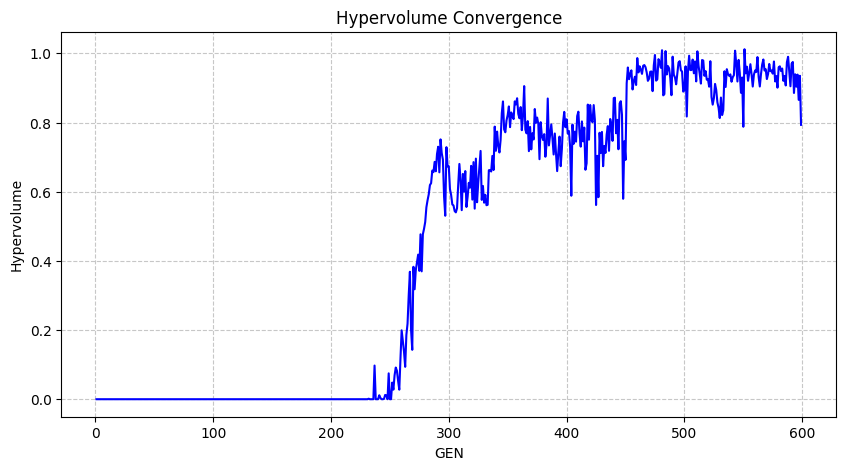

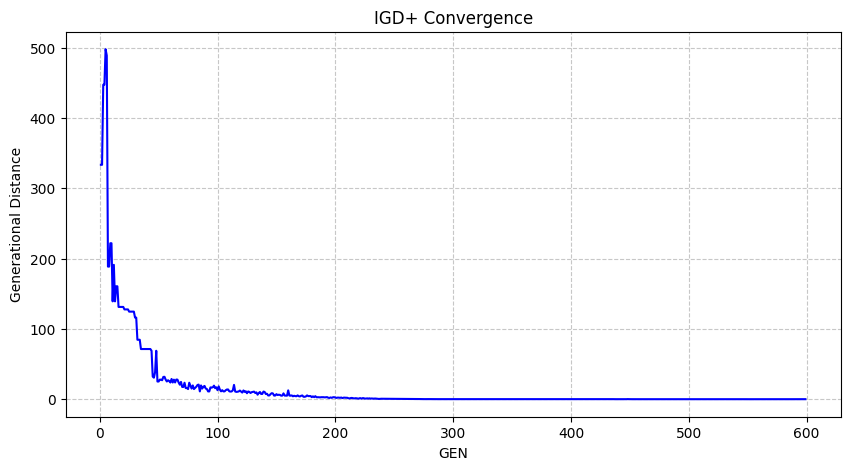

In [6]:
import matplotlib.pyplot as plt


for ind in pop:
   print(ind)

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()